In [1]:
import os
import pandas as pd
import joblib
import numpy as np
from operator import add
from functools import partial
from typing import TypedDict, List, Tuple, Literal, Dict, Annotated
from langgraph.graph import StateGraph, END
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.schema import Document
from langchain.document_loaders import PyPDFLoader, CSVLoader, TextLoader
from langchain.retrievers import BM25Retriever, EnsembleRetriever, ContextualCompressionRetriever
from langchain.retrievers.document_compressors import EmbeddingsFilter
from pydantic import BaseModel, Field

In [2]:
MODEL = 'granite4:latest'
llm = ChatOllama(model=MODEL, num_ctx=15768)
embeddings = OllamaEmbeddings(model=MODEL)

In [ ]:
# df = pd.read_csv('data/data2.csv')
# data_imp = df[['Study Title', 'Study URL', 'Study Status', 'Brief Summary', 'Study Results',
#                'Conditions', 'Interventions', 'Primary Outcome Measures', 'Secondary Outcome Measures',
#                'Other Outcome Measures']].sample(frac=0.4)
# with open('data/data2_processed.txt', 'w+', encoding='utf-8') as f:
#     for _, row in data_imp.iterrows():
#         for col in data_imp.columns:
#             f.write(f"{col}: {row[col]}\n")
#         f.write('\n\n')

# df = pd.read_csv('data/data1.csv')
# with open('data/abstracts.txt', 'w+', encoding='utf-8') as f:
#     for abstract in df['abstract_text'].sample(frac=0.4):
#         f.write(abstract + '\n\n')


In [15]:
book1 = PyPDFLoader('data/book1.pdf').load()
book2 = PyPDFLoader('data/book2.pdf').load()
abs1 = TextLoader('data/fragmented/abstracts1.txt', encoding='utf-8').load()
data2 = TextLoader('data/fragmented/clinical_reports.txt', encoding='utf-8').load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=600, chunk_overlap=200)
documents = []
for doc in [book1, book2]:
    documents.extend(text_splitter.split_documents(doc))

text_splitter_5k = RecursiveCharacterTextSplitter(chunk_size=6000, chunk_overlap=1500)
for doc in [abs1, data2]:
    documents.extend(text_splitter_5k.split_documents(doc))

In [16]:
len(documents) # 5815

271

In [17]:
from tqdm.auto import tqdm
import numpy as np

embedded_docs = []
for doc in tqdm(documents):
    vector = embeddings.embed_documents([doc.page_content])[0]
    embedded_docs.append((doc, vector))

100%|██████████| 271/271 [00:42<00:00,  6.32it/s]


In [87]:
import joblib
joblib.dump(embedded_docs, 'data/embedded_docs_sample.joblib')
len(embedded_docs)

271

In [18]:
# embedded_docs = np.load('data/embedded_docs.npy', allow_pickle=True)
loaded_docs = embedded_docs # joblib.load('data/embedded_docs.joblib')
docs = [d for d, _ in loaded_docs]
vectors = [v for _, v in loaded_docs]

In [19]:
len(vectors[0]), len(vectors)

(2560, 271)

In [20]:
with open('data/all_content.txt', 'w+', encoding='utf-8') as f:
    f.write(''.join([d.page_content for d in docs]))

In [21]:
normalized_docs = [(d, v/np.linalg.norm(v)) for d, v in loaded_docs]

In [34]:
research_data = [d for d in normalized_docs if d[0].metadata['source'] in ['data/abstracts.txt', 'data/fragmented/abstracts1.txt']]
book_data = [d for d in normalized_docs if d[0].metadata['source'] in ['data/book1.pdf', 'data/book2.pdf']]
clinical_data = [d for d in normalized_docs if d[0].metadata['source'] in ['data/fragmented/clinical_reports.txt', 'data/data2_processed.txt']]

In [89]:
joblib.dump(research_data, 'data/vectors/research_data_sample.joblib')
joblib.dump(book_data, 'data/vectors/book_data_sample.joblib')
joblib.dump(clinical_data, 'data/vectors/clinical_data_sample.joblib')

['data/vectors/clinical_data_sample.joblib']

In [35]:
len(research_data), len(book_data), len(clinical_data)

(9, 240, 22)

In [36]:
def build_retriever(data: List[tuple[Document, List[float]]], k:int = 10, weights: List[float] = [0.6, 0.4]) -> ContextualCompressionRetriever:
    vector_store  = FAISS.from_embeddings(text_embeddings=[(d.page_content, v) for d, v in data], 
                                          embedding=embeddings,
                                          metadatas=[d.metadata for d, _ in data])
    vector_retriever = vector_store.as_retriever(k=k)

    keyword_retriever = BM25Retriever.from_documents([d for d , _ in data])
    keyword_retriever.k = k

    ensemble_retriever = EnsembleRetriever(retrievers=[vector_retriever, keyword_retriever],
                                           weights=weights)

    embedding_filter = EmbeddingsFilter(embeddings=embeddings, similarity_threshold=0.52)
    filtered_retriever = ContextualCompressionRetriever(base_compressor=embedding_filter, base_retriever=ensemble_retriever)

    return filtered_retriever

research_retriever = build_retriever(research_data, weights=[0.7, 0.3])
book_retriever = build_retriever(book_data, weights=[0.5, 0.5])
clinical_retriever = build_retriever(clinical_data, weights=[0.6, 0.4])

In [37]:
# clinical_retriever.invoke("What are the steps to treat type 2 diabetes?")
retrievers = {
    'research': research_retriever,
    'book': book_retriever,
    'clinic': clinical_retriever
}

In [38]:
class MasterAgentState(TypedDict):
    question: str
    queries: Dict[Literal['clinic', 'research', 'book'], str]
    contexts: Annotated[List[Tuple[str, str]], add]
    answer: str
    
class MasterQuery(BaseModel):
    queries: Dict[Literal['clinic', 'research', 'book'], str] = Field(description="Dictionary of {agent_type : query}. query will be passed to the vector store of respective agent_type")

In [39]:
query = "What are steps to treat diabetes 2?"

def master_query_node(state: MasterAgentState) -> MasterAgentState:
    query = state['question']

    prompt_master = r"""
You are a **Master Routing Agent** responsible for delegating a user's medical question to the most relevant specialized Worker Agents. 
Each Worker Agent has access to a unique document vector store, all related to **diabetes management**.

Your job:
1. Analyze the question’s intent (clinical outcomes, research findings, or practical management).
2. Decide which Worker Agent(s) should receive the query. 
   - You may select one, two, or all three agents, but include each agent only once.
3. Generate **worker-specific, context-rich sub-queries** that use domain-relevant terminology, synonyms, and keywords found or implied in the question.

Available Worker Agents:
- **clinic** → Clinical trials, outcomes, interventions, patient cohorts, and treatment efficacy.
- **research** → Biomedical studies, molecular mechanisms, pharmacological actions, and evidence synthesis.
- **book** → Medical textbooks, care guidelines, information about diabetes disease and medication and lifestyle management practices for diabetes.

If unsure, include all three agents to maximize coverage, but customize each sub-query to the data type they handle.

Output format:
{
  "clinic": "...query tailored for clinical data...",
  "research": "...query tailored for research abstracts...",
  "book": "...query tailored for practical/lifestyle information..."
}

When generating queries:
- Use worker-specific terminology (e.g., “trial outcomes” for clinic, “mechanisms” for research, “self-care” for book).
- Rephrase or expand user questions with relevant keywords (e.g., drug names, biomarkers, outcome measures).
- Keep queries concise but information-rich.
- During query formation add domain-related synonyms and related terms to enhance retrieval effectiveness.

Query:
""" + query


    initial_agent = llm.with_structured_output(MasterQuery)
    res = initial_agent.invoke(input=prompt_master)
    assert isinstance(res, MasterQuery), "Master query Failed"
    return {**state, 'queries': res.queries, 'contexts': [] }



def worker_node(state: MasterAgentState, worker_name: Literal['clinic', 'research', 'book']):
    query = state["queries"].get(worker_name)
    if query is None:
        return {**state}
    retriever = retrievers[worker_name]
    docs = retriever.invoke(query)
    context_chunks = []
    for doc in docs:
        source_info = doc.metadata['source']
        context_chunks.append(f"Source: {source_info}\nContent: {doc.page_content}")
    context = "\n\n---\n\n".join(context_chunks)
    return {'contexts': [(worker_name, context)]}


def master_synthesizer_node(state: MasterAgentState) -> MasterAgentState:
    question = state["question"]
    context_str = ""
    for agent_name, context in state['contexts']:
        context_str += f"--- Context from {agent_name} ---\n{context}\n\n"
    prompt = f"""
    You are an expert medical research assistant. You have received context from several specialized agents.
    - Prioritize evidence that directly addresses the user's question.
    - Explicitly mention which source each claim is drawn from.
    - Do NOT invent or infer beyond what is supported by the provided context.
    - If there is conflicting information, state it clearly.

    {context_str}

    Original Question: {question}
    Final, evidence-based answer:
    """

    
    res = llm.invoke(prompt).content
    assert isinstance(res, str), "Final answer generation failed"
    return {**state, "answer": res}

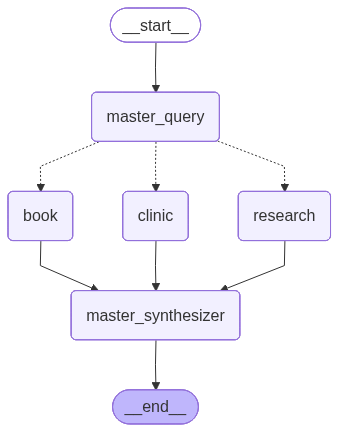

In [40]:
def route_to_workers(state: MasterAgentState) -> List[str]:
    return list(state["queries"].keys())

graph = StateGraph(MasterAgentState)

graph.set_entry_point('master_query')
graph.add_node("master_query", master_query_node)

graph.add_node('clinic', partial(worker_node, worker_name='clinic'))
graph.add_node('research', partial(worker_node, worker_name='research'))
graph.add_node('book', partial(worker_node, worker_name='book'))

graph.add_node('master_synthesizer', master_synthesizer_node)

graph.add_conditional_edges(
    "master_query",
    route_to_workers,
    {
        'clinic': 'clinic',
        'research': 'research',
        'book': 'book'
    }
)

graph.add_edge('clinic', 'master_synthesizer')
graph.add_edge('research', 'master_synthesizer')
graph.add_edge('book', 'master_synthesizer')
graph.set_finish_point('master_synthesizer')


app = graph.compile()
app

In [41]:
def ask_question(question: str) -> MasterAgentState:
    initial_state: MasterAgentState = {
        'question': question,
        'queries': {},
        'contexts': [],
        'answer': ''
    }
    final_state = app.invoke(initial_state)
    return final_state

In [42]:
res1 = ask_question('How does a diabetes nurse consultant–led treat-to-target clinic compare with usual clinic-based care in improving metabolic control, self-efficacy, and healthcare utilization among patients with type 2 diabetes over a 12-month period?')

print(res1['answer'])

**Answer**

A diabetes nurse consultant‑led *treat‑to‑target* (T2T) clinic significantly improves metabolic control, patient self‑efficacy, and healthcare utilization among adults with type 2 diabetes compared with standard clinic care over a 12‑month period.

**Key Findings from the Clinical Evidence**

1. **Meta‑analysis of treat‑to‑target interventions**  
   - A systematic review/meta‑analysis (Medicine 2019) reported that *treat‑to‑target* approaches reduced HbA₁c by **0.4–0.5 %**, a clinically meaningful improvement, compared with usual care (pooled risk ratio 0.82; 95 % CI 0.78‑0.86).  
   - The reduction in HbA₁c was dose‑dependent and persisted across different populations and treatment regimens.

2. **Specific trial outcomes**  
   - **DPP‑4 inhibitor + insulin** study (NCT05147961) demonstrated a lower incidence of hypoglycaemia and fewer adverse events in the T2T group versus standard care, reinforcing that targeted glycemic control is feasible without excessive risk.  
   

In [44]:
res1['queries']

{'clinic': 'Comparative effectiveness study of treat-to-target clinics led by diabetes nurse consultants versus standard outpatient care on glycated hemoglobin, adverse events, emergency department visits, and medication adherence in adults with type 2 diabetes over 12 months.',
 'research': 'Meta-analysis examining the impact of nurse-led treat-to-target protocols versus conventional management on glycosylated hemoglobin A1c reduction rates, cardiovascular risk markers, psychological empowerment (self-efficacy), and resource utilization metrics among patients diagnosed with T2DM longitudinally.',
 'book': 'Guidelines for implementing a treat-to-target approach in diabetes care under the supervision of certified diabetes nurse educators versus standard practice protocols focusing on patient-centered goals, lifestyle modifications, and medication adjustment strategies to optimize HbA1c levels within 12 months.'}

In [45]:
res1['contexts']

[('book',
  'Source: data/book2.pdf\nContent: should be encouraged to decrease proinflammatory fats and enhance omega-3 intake while \nreducing the intake of omega-6 fats.  This can result in an 83% reduction in diabetes \nincidence, with 0.1%-0.6% reduction in HgbA1C.[4]  For more information, refer to “The \nAnti-Inflammatory Lifestyle” and the “Choosing a Diet” Whole Health tool.\n\n---\n\nSource: data/book1.pdf\nContent: have type 2 diabetes often experience ED earlier in life than men without the condition. Other factors that can cause ED are:\n  •  High blood pressure\n  •  Kidney disease\n  •  Alcoholism\n  •  Blood vessel disease\n  •  Some medications\n  •  Psychological distress\n  •  Smoking\n  •  Hormone deficiency\nFor ED that is caused by nerve damage, treatments include:\n  •  Oral medicine\n  •  A vacuum pump\n  •  Urethral implants \n  •  Injections \n  •  Surgery\nTalk with your doctor about recommendations for treating ED and how to manage type 2 diabetes to maintain

In [46]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ContextRecall, ContextPrecision, ContextPrecision
from ragas import EvaluationDataset
from tqdm.auto import tqdm

In [76]:
questions = [
    "What was the primary goal of the Effects of Sitagliptin on Endothelial Function in Type 2 Diabetes study?",
    "How long were patients treated with sitagliptin and placebo in the sitagliptin trial?",
    "What was the purpose of the Set-Point Study involving the bionic pancreas?",
    "What were the main outcomes measured in the Set-Point Study?",
    "What was evaluated in the LX4211 and Metformin Interaction Study?",
    "According to the VA Whole Health recommendations, how much can a low glycemic index diet reduce HbA1c levels?",
    "What are the key dietary principles of the Mediterranean diet for managing type 2 diabetes?",
    "What percentage of weight loss is recommended to improve insulin action in type 2 diabetes patients?",
    "Which supplements are generally recommended routinely for overall health in diabetic patients?",
    "What lifestyle recommendations are given to manage blood glucose through exercise?"
]

ground_truths = [
    "The primary goal was to determine whether sitagliptin, a DPP-4 inhibitor, acutely and chronically improves blood vessel function in patients with type 2 diabetes on metformin.",
    "Patients received sitagliptin for 8 weeks and a matching placebo for another 8 weeks, separated by a 4-week washout period.",
    "The Set-Point Study aimed to evaluate how changing glucose targets affects the performance of a bi-hormonal bionic pancreas in managing glucose levels and preventing hypoglycemia.",
    "Main outcomes included mean CGM glucose levels, percentage of time spent in hypoglycemia (<60 mg/dl), and insulin/glucagon dosing during exercise visits.",
    "The LX4211 and Metformin Interaction Study assessed how LX4211 and metformin affect each other’s plasma concentrations when taken together as single doses.",
    "A low glycemic index (GI) diet can reduce hemoglobin A1c (HbA1c) by approximately 0.4%–0.5%.",
    "The Mediterranean diet emphasizes reducing pro-inflammatory fats, increasing omega-3 intake, and consuming more plant-based, anti-inflammatory foods, potentially reducing diabetes incidence by up to 83%.",
    "A 5% weight loss from baseline body weight is recommended to improve insulin sensitivity, lower fasting blood glucose, and reduce medication dependence.",
    "Fiber, fish oil, and vitamin D are routinely recommended supplements for diabetic patients to support overall metabolic and cardiovascular health.",
    "Patients are encouraged to perform at least 30 minutes of physical activity daily, including walking or resistance exercises, to improve insulin use, control glucose, and prevent complications."
]

dataset = []
for query, ground_truth in tqdm(zip(questions, ground_truths)):
    res = ask_question(query)
    dataset.append({
        'user_input': query,
        'retrieved_contexts': [f"{agent}: {context}" for agent, context in res['contexts'] if context.strip() != ''],
        'reference': ground_truth,
        'response': res['answer']
    })

10it [07:49, 46.99s/it]


In [77]:
# joblib.dump(dataset, 'data/evaluation_dataset.joblib')

['data/evaluation_dataset.joblib']

In [ ]:
# import joblib

dataset = joblib.load('data/evaluation_dataset.joblib')

In [ ]:
# for d in dataset:
#     # d['user_input'] = d['question']
#     # d['response'] = d['answer']
#     # d['reference'] = d['ground_truth']
#     d['retrieved_contexts'] = [f"{agent}: {context}" for agent, context in d['retrieved_contexts'] if context.strip() != '']
#     # del d['generated_queries']

# for d in dataset:
#     d['retrieved_contexts'] = [f"{context[:1200]}" for context in d['retrieved_contexts'] if context.strip() != '']

In [80]:
dataset[4]

{'user_input': 'What was evaluated in the LX4211 and Metformin Interaction Study?',
 'retrieved_contexts': ['book: Source: data/book1.pdf\nContent: •  Vaginal dryness with accompanying pain or discomfort during sex\nIn addition to type 2 diabetes, other causes of a woman’s lack of sexual desire include:\n  •  Blood pressure medicine\n  •  Various prescription and over-the-counter medicines\n  •  Alcohol abuse\n  •  Smoking\n  •  Psychological issues\n  •  Gynecologic infections\n  •  Conditions relating to pregnancy or menopause\nTalk with your health care team, including your gynecologist, about how to manage type 2 diabetes and what to do to help \nfemale sexual dysfunction. Some methods used to treat the condition are: \n  • Kegel exercises\n\n---\n\nSource: data/book1.pdf\nContent: In people with type 2 diabetes, sexual dysfunction can be the result of damage to the nerves that regulate sexual response. This \nnerve damage is called neuropathy. For men, this can mean problems achie

In [81]:
evaluation_dataset = EvaluationDataset.from_list(dataset[:3])

In [82]:
# from langchain_openai import  ChatOpenAI
# from dotenv import load_dotenv
# import os

# load_dotenv()

# eval_llm = ChatOpenAI(name='gpt-5-nano', temperature=0, api_key=os.getenv('OPENAI_API_KEY'))
# eval_llm

ChatOpenAI(name='gpt-5-nano', client=<openai.resources.chat.completions.completions.Completions object at 0x0000020FEBB4A510>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000020FEBB4ABA0>, root_client=<openai.OpenAI object at 0x0000020FEE441E50>, root_async_client=<openai.AsyncOpenAI object at 0x0000020FEE442AD0>, temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

In [85]:
from langchain.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

llm_eval = ChatOllama(
    model="mistral:latest",
    temperature=0,
    num_ctx=15024
)


In [86]:
from ragas.run_config import RunConfig
from ragas.metrics import context_recall, answer_similarity, context_precision, faithfulness

config = RunConfig(
    timeout=180,
    max_retries=1,
)

evaluator_llm = LangchainLLMWrapper(llm_eval)
# evaluator_llm = LangchainLLMWrapper(eval_llm)


result = evaluate(dataset=evaluation_dataset,metrics=[context_precision, faithfulness],
                   #Faithfulness(), FactualCorrectness(), ContextRecall(), ContextPrecision()],
                  llm=evaluator_llm, run_config=config)
result

C:\Users\dasha\AppData\Local\Temp\ipykernel_9024\1600731856.py:9: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  evaluator_llm = LangchainLLMWrapper(llm_eval)
Evaluating:  17%|█▋        | 1/6 [02:39<13:19, 159.81s/it]Exception raised in Job[1]: TimeoutError()
Exception raised in Job[2]: TimeoutError()
Exception raised in Job[3]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Exception raised in Job[0]: TimeoutError()
Evaluating: 100%|██████████| 6/6 [03:00<00:00, 30.00s/it] 


{'context_precision': nan, 'faithfulness': 0.0000}

In [ ]:
# factual_correctness(mode=f1)': 0.8300, 'answer_similarity': 0.9336, 'context_recall': 1.0000